<a href="https://colab.research.google.com/github/bishaarabdi1/artificial-intelligence-/blob/main/machine-learning%5Csomalifoodprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("somali food predictions.csv")

df.head()

,Unnamed: 0,Country,Region,Market,Product,Date,Open,High,Low,Close,Currency
0,NaN,Somalia,Market Average,Market Average,food_price_index,2007-01-01,0.20,0.21,0.20,0.21,SOS
1,NaN,Somalia,Market Average,Market Average,food_price_index,2007-02-01,0.21,0.22,0.20,0.20,SOS
2,NaN,Somalia,Market Average,Market Average,food_price_index,2007-03-01,0.21,0.24,0.20,0.24,SOS
3,NaN,Somalia,Market Average,Market Average,food_price_index,2007-04-01,0.25,0.26,0.24,0.24,SOS
4,NaN,Somalia,Market Average,Market Average,food_price_index,2007-05-01,0.25,0.25,0.24,0.24,SOS


In [3]:
df.shape

(3304, 11)

In [4]:
df.columns

Index(['Unnamed: 0', 'Country', 'Region', 'Market', 'Product', 'Date', 'Open',
       'High', 'Low', 'Close', 'Currency'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3304 entries, 0 to 3303
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  0 non-null      float64
 1   Country     3304 non-null   object 
 2   Region      3304 non-null   object 
 3   Market      3304 non-null   object 
 4   Product     3304 non-null   object 
 5   Date        3304 non-null   object 
 6   Open        3304 non-null   float64
 7   High        3304 non-null   float64
 8   Low         3304 non-null   float64
 9   Close       3304 non-null   float64
 10  Currency    3304 non-null   object 
dtypes: float64(5), object(6)
memory usage: 284.1+ KB


In [6]:
df.isnull().sum()

,0
Unnamed: 0,3304
Country,0
Region,0
Market,0
Product,0
Date,0
Open,0
High,0
Low,0
Close,0


In [7]:
df["Product"].value_counts()

,count
Product,
food_price_index,236
livestock_camel_fao,236
livestock_goat_fao,236
maize,236
maize_fao,236
milk,236
milk_fao,236
oil,236
rice,236


In [8]:
df["Market"].value_counts()

,count
Market,
Market Average,3304


EDA ANALYSES

In [9]:
new_df = df.copy()

In [10]:
new_df = new_df.drop(columns=["Unnamed: 0"])

In [11]:
new_df["Date"] = pd.to_datetime(new_df["Date"])

In [12]:
new_df = new_df.sort_values(["Product", "Date"])

In [13]:
new_df = new_df.reset_index(drop=True)

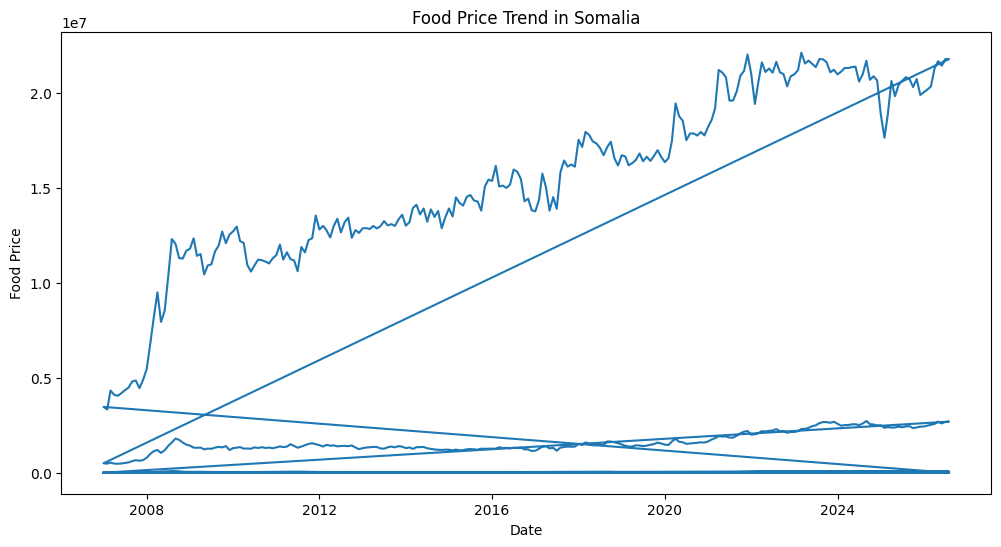

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    new_df["Date"],
    new_df["Close"]
)

plt.xlabel("Date")
plt.ylabel("Food Price")
plt.title("Food Price Trend in Somalia")

plt.show()

In [15]:
new_df["Product"].value_counts()

,count
Product,
food_price_index,236
livestock_camel_fao,236
livestock_goat_fao,236
maize,236
maize_fao,236
milk,236
milk_fao,236
oil,236
rice,236


In [16]:
new_df["Product"].unique()

array(['food_price_index', 'livestock_camel_fao', 'livestock_goat_fao',
       'maize', 'maize_fao', 'milk', 'milk_fao', 'oil', 'rice',
       'rice_fao', 'sorghum', 'sorghum_fao', 'wheat_fao',
       'wheat_flour_fao'], dtype=object)

In [17]:
product_avg = new_df.groupby("Product")["Close"].mean().sort_values()

print(product_avg)

Product
food_price_index       8.914831e-01
maize_fao              8.861020e+03
sorghum_fao            8.977104e+03
maize                  9.438705e+03
sorghum                9.659035e+03
wheat_flour_fao        1.399736e+04
wheat_fao              1.495372e+04
rice_fao               1.590043e+04
rice                   1.792532e+04
milk                   2.393381e+04
oil                    3.589182e+04
milk_fao               3.969274e+04
livestock_goat_fao     1.600904e+06
livestock_camel_fao    1.535201e+07
Name: Close, dtype: float64


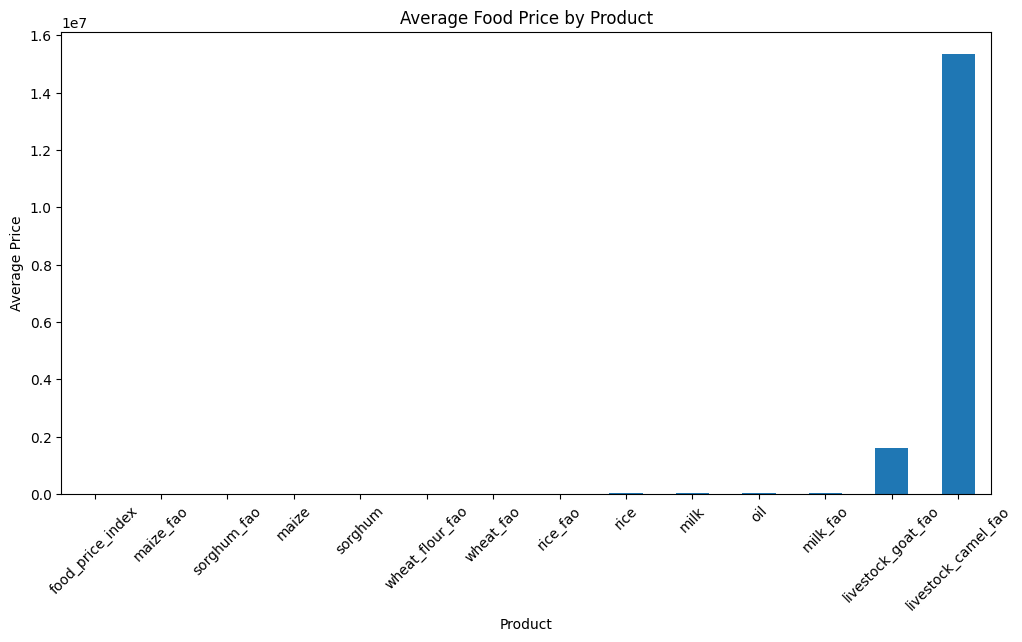

In [18]:
plt.figure(figsize=(12, 6))

product_avg.plot(kind="bar")

plt.xlabel("Product")
plt.ylabel("Average Price")
plt.title("Average Food Price by Product")

plt.xticks(rotation=45)
plt.show()

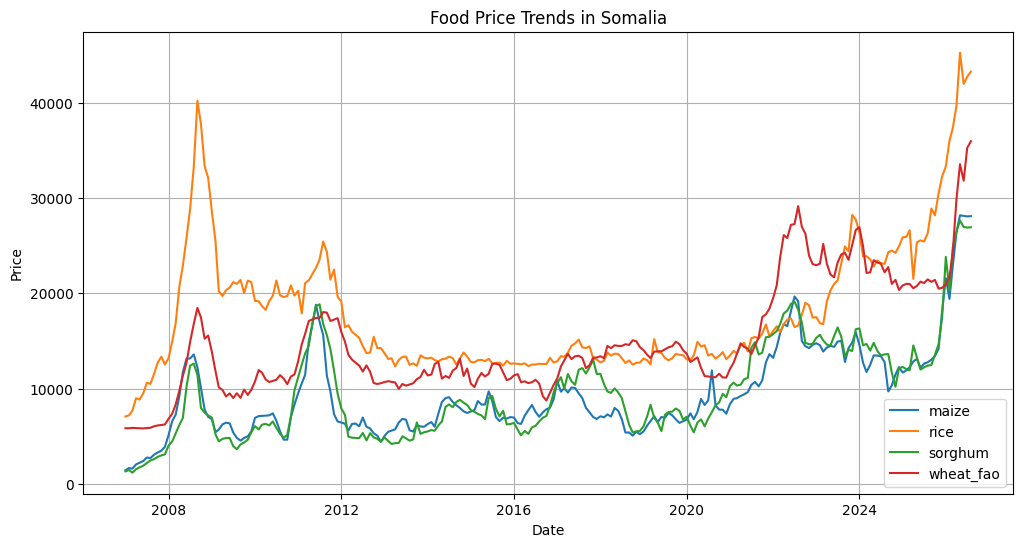

In [19]:
products = ["maize", "rice", "sorghum", "wheat_fao"]

plt.figure(figsize=(12, 6))

for product in products:
    product_data = new_df[new_df["Product"] == product]

    plt.plot(
        product_data["Date"],
        product_data["Close"],
        label=product
    )

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Food Price Trends in Somalia")

plt.legend()
plt.grid(True)

plt.show()

<Figure size 1200x600 with 0 Axes>

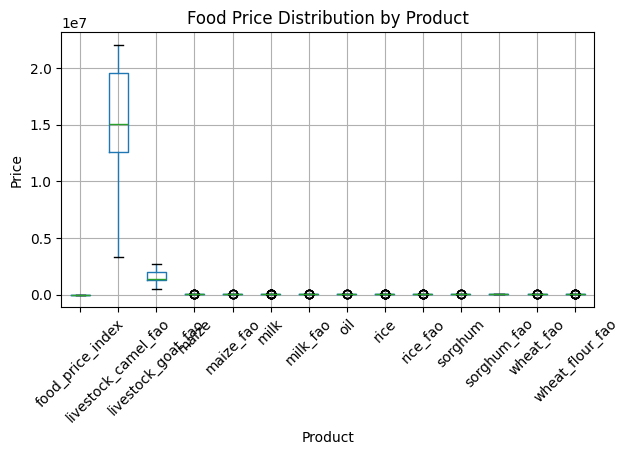

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

new_df.boxplot(
    column="Close",
    by="Product",
    rot=45
)

plt.title("Food Price Distribution by Product")
plt.suptitle("")
plt.xlabel("Product")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

In [21]:
new_df.groupby("Product")["Close"].agg(
    ["mean", "min", "max", "std"]
).sort_values("mean")

,mean,min,max,std
Product,,,,
food_price_index,8.914831e-01,0.20,1.28,2.601487e-01
maize_fao,8.861020e+03,1457.96,20295.39,3.654598e+03
sorghum_fao,8.977104e+03,1349.78,19341.03,4.061876e+03
maize,9.438705e+03,1461.96,28180.44,4.757624e+03
sorghum,9.659035e+03,1201.99,27628.65,5.188368e+03
wheat_flour_fao,1.399736e+04,8065.57,32504.17,3.683801e+03
wheat_fao,1.495372e+04,5846.64,35942.57,5.887808e+03
rice_fao,1.590043e+04,7076.88,37268.01,4.288926e+03
rice,1.792532e+04,7097.20,45218.36,6.952260e+03


In [22]:
new_df["Year"] = new_df["Date"].dt.year
new_df["Month"] = new_df["Date"].dt.month

In [23]:
new_df[["Date", "Year", "Month"]].head()

,Date,Year,Month
0,2007-01-01,2007,1
1,2007-02-01,2007,2
2,2007-03-01,2007,3
3,2007-04-01,2007,4
4,2007-05-01,2007,5


In [24]:
new_df["Close_lag_1"] = new_df.groupby("Product")["Close"].shift(1)

new_df["Close_lag_2"] = new_df.groupby("Product")["Close"].shift(2)

new_df["Close_lag_3"] = new_df.groupby("Product")["Close"].shift(3)

In [25]:
new_df[
    [
        "Product",
        "Date",
        "Close",
        "Close_lag_1",
        "Close_lag_2",
        "Close_lag_3"
    ]
].head(10)

,Product,Date,Close,Close_lag_1,Close_lag_2,Close_lag_3
0,food_price_index,2007-01-01,0.21,NaN,NaN,NaN
1,food_price_index,2007-02-01,0.20,0.21,NaN,NaN
2,food_price_index,2007-03-01,0.24,0.20,0.21,NaN
3,food_price_index,2007-04-01,0.24,0.24,0.20,0.21
4,food_price_index,2007-05-01,0.24,0.24,0.24,0.20
5,food_price_index,2007-06-01,0.24,0.24,0.24,0.24
6,food_price_index,2007-07-01,0.26,0.24,0.24,0.24
7,food_price_index,2007-08-01,0.28,0.26,0.24,0.24
8,food_price_index,2007-09-01,0.30,0.28,0.26,0.24
9,food_price_index,2007-10-01,0.33,0.30,0.28,0.26


In [26]:
new_df = new_df.dropna().copy()

new_df.head()

,Country,Region,Market,Product,Date,Open,High,Low,Close,Currency,Year,Month,Close_lag_1,Close_lag_2,Close_lag_3
3,Somalia,Market Average,Market Average,food_price_index,2007-04-01,0.25,0.26,0.24,0.24,SOS,2007,4,0.24,0.20,0.21
4,Somalia,Market Average,Market Average,food_price_index,2007-05-01,0.25,0.25,0.24,0.24,SOS,2007,5,0.24,0.24,0.20
5,Somalia,Market Average,Market Average,food_price_index,2007-06-01,0.24,0.25,0.24,0.24,SOS,2007,6,0.24,0.24,0.24
6,Somalia,Market Average,Market Average,food_price_index,2007-07-01,0.25,0.26,0.24,0.26,SOS,2007,7,0.24,0.24,0.24
7,Somalia,Market Average,Market Average,food_price_index,2007-08-01,0.27,0.28,0.26,0.28,SOS,2007,8,0.26,0.24,0.24


In [27]:
new_df.shape

(3262, 15)

In [28]:
features = [
    "Year",
    "Month",
    "Close_lag_1",
    "Close_lag_2",
    "Close_lag_3"
]

X = new_df[features]
y = new_df["Close"]

In [29]:
new_df.columns

Index(['Country', 'Region', 'Market', 'Product', 'Date', 'Open', 'High', 'Low',
       'Close', 'Currency', 'Year', 'Month', 'Close_lag_1', 'Close_lag_2',
       'Close_lag_3'],
      dtype='object')

In [30]:
features = [
    "Product",
    "Year",
    "Month",
    "Close_lag_1",
    "Close_lag_2",
    "Close_lag_3"
]

X = new_df[features].copy()
y = new_df["Close"].copy()

X.head()

,Product,Year,Month,Close_lag_1,Close_lag_2,Close_lag_3
3,food_price_index,2007,4,0.24,0.20,0.21
4,food_price_index,2007,5,0.24,0.24,0.20
5,food_price_index,2007,6,0.24,0.24,0.24
6,food_price_index,2007,7,0.24,0.24,0.24
7,food_price_index,2007,8,0.26,0.24,0.24


One-Hot Encoding.

In [31]:
X = pd.get_dummies(
    X,
    columns=["Product"],
    drop_first=False
)

X.head()

,Year,Month,Close_lag_1,Close_lag_2,Close_lag_3,Product_food_price_index,Product_livestock_camel_fao,Product_livestock_goat_fao,Product_maize,Product_maize_fao,Product_milk,Product_milk_fao,Product_oil,Product_rice,Product_rice_fao,Product_sorghum,Product_sorghum_fao,Product_wheat_fao,Product_wheat_flour_fao
3,2007,4,0.24,0.20,0.21,True,False,False,False,False,False,False,False,False,False,False,False,False,False
4,2007,5,0.24,0.24,0.20,True,False,False,False,False,False,False,False,False,False,False,False,False,False
5,2007,6,0.24,0.24,0.24,True,False,False,False,False,False,False,False,False,False,False,False,False,False
6,2007,7,0.24,0.24,0.24,True,False,False,False,False,False,False,False,False,False,False,False,False,False
7,2007,8,0.26,0.24,0.24,True,False,False,False,False,False,False,False,False,False,False,False,False,False


In [32]:
X.shape

(3262, 19)

Train/Test Split.

In [33]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2609, 19)
X_test: (653, 19)
y_train: (2609,)
y_test: (653,)


In [34]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [35]:
y_pred = model.predict(X_test)

y_pred[:10]

array([11444.7593 , 13198.73055, 15387.26465, 14934.555  , 17511.5919 ,
       18685.9928 , 18351.37665, 16017.38695, 14015.5038 , 13103.9273 ])

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 761.1645448698313
RMSE: 1071.0335031549314
R² Score: 0.9553286359582411


In [37]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,12542.69,11444.75930
1,14824.92,13198.73055
2,14444.64,15387.26465
3,16589.29,14934.55500
4,18386.81,17511.59190
5,18697.25,18685.99280
6,16580.46,18351.37665
7,15547.74,16017.38695
8,14142.80,14015.50380
9,11895.62,13103.92730


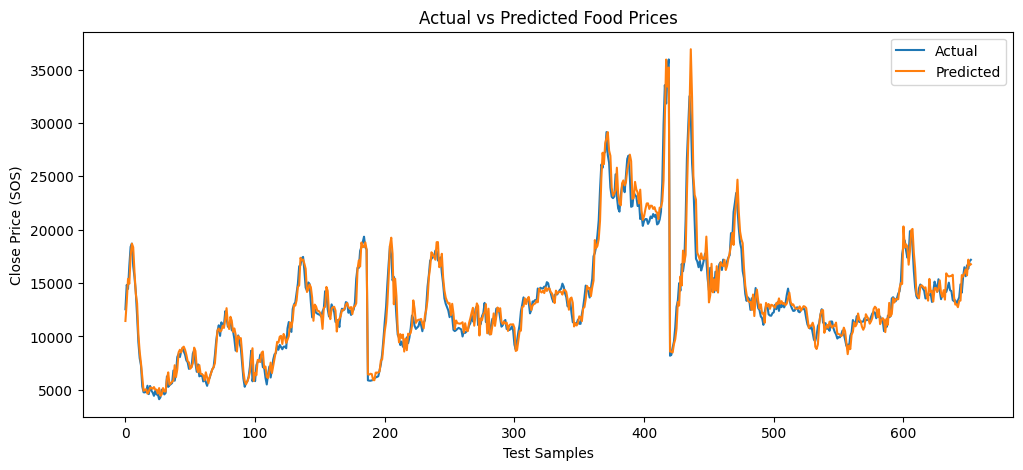

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.xlabel("Test Samples")
plt.ylabel("Close Price (SOS)")
plt.title("Actual vs Predicted Food Prices")

plt.legend()
plt.show()

In [40]:
new_df.to_csv("CLEAN somali_food_predictions.csv", index=False)